In [1]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_6): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.visualization.distribution_collector import collect_top_bottom_tags
from matplotlib import pyplot as plt
import lib.visualization.plot_generator as PlotGen

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()




Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [3]:
viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")


output_dir = './fig/'
date_range = 'Weekly'

std_date = Date_Setting[option_dict['year_range']]['std_date']
# pre_std_date = datetime.datetime(2021, 12, 1)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/hdd/mghan/so_data_availability/result/tag/run_id_14/option.json'

In [4]:
df = load_df(data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])

In [5]:
df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
df['rel_week'] = np.floor((df['cdate']-std_date).dt.days/7)

'typescript'

In [7]:
proportion_dict = dict()
proportion_dict = collect_top_bottom_tags(df)

In [8]:
proportion_dict

{'Top 20% Tags':      rel_week   pct_pct
 0      -104.0  0.996018
 1      -103.0  0.994782
 2      -102.0  0.995575
 3      -101.0  0.994591
 4      -100.0  0.996386
 ..        ...       ...
 255     151.0  0.948529
 256     152.0  0.932796
 257     153.0  0.877193
 258     154.0  0.909091
 259     155.0  0.935185
 
 [260 rows x 2 columns],
 'Bottom 20% Tags':      rel_week   pct_pct
 0      -104.0  0.003982
 1      -103.0  0.005218
 2      -102.0  0.004425
 3      -101.0  0.005409
 4      -100.0  0.003614
 ..        ...       ...
 242     145.0  0.008621
 243     146.0  0.017241
 244     147.0  0.025000
 245     148.0  0.021739
 246     149.0  0.018519
 
 [247 rows x 2 columns]}

In [9]:
color_list = ["#4C704C", "#A3C9A8"]

In [10]:
def plot_regression(ax, values, title, ylabel=None):
    
    list_ = list(values)
    x_rel, divider = get_dist_x_param_div(list_, 52)

    reg_bf = calc_regression_with_ci(x_rel[:divider], list_[:divider])
    reg_af = calc_regression_with_ci(x_rel[divider:], list_[divider:])

    bf = reg_bf["pred_summary"]
    af = reg_af["pred_summary"]

    ax.scatter(x_rel, list_, color='darkgray', alpha=0.7, s=10, marker='x')
    ax.axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)

    ax.plot(x_rel[:divider], bf["mean"], linewidth=2, label='before ChatGPT')
    ax.plot(x_rel[divider:], af["mean"], linewidth=2, label='after ChatGPT')

    ax.fill_between(x_rel[:divider], bf["mean_ci_lower"], bf["mean_ci_upper"], alpha=0.1)
    ax.fill_between(x_rel[divider:], af["mean_ci_lower"], af["mean_ci_upper"], alpha=0.1)

    ax.legend(frameon=False, loc='best', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.text(
        0.5, 1.05, title,
        ha='center', va='bottom',
        fontsize=22, fontweight='bold',
        transform=ax.transAxes
    )

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22)

    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

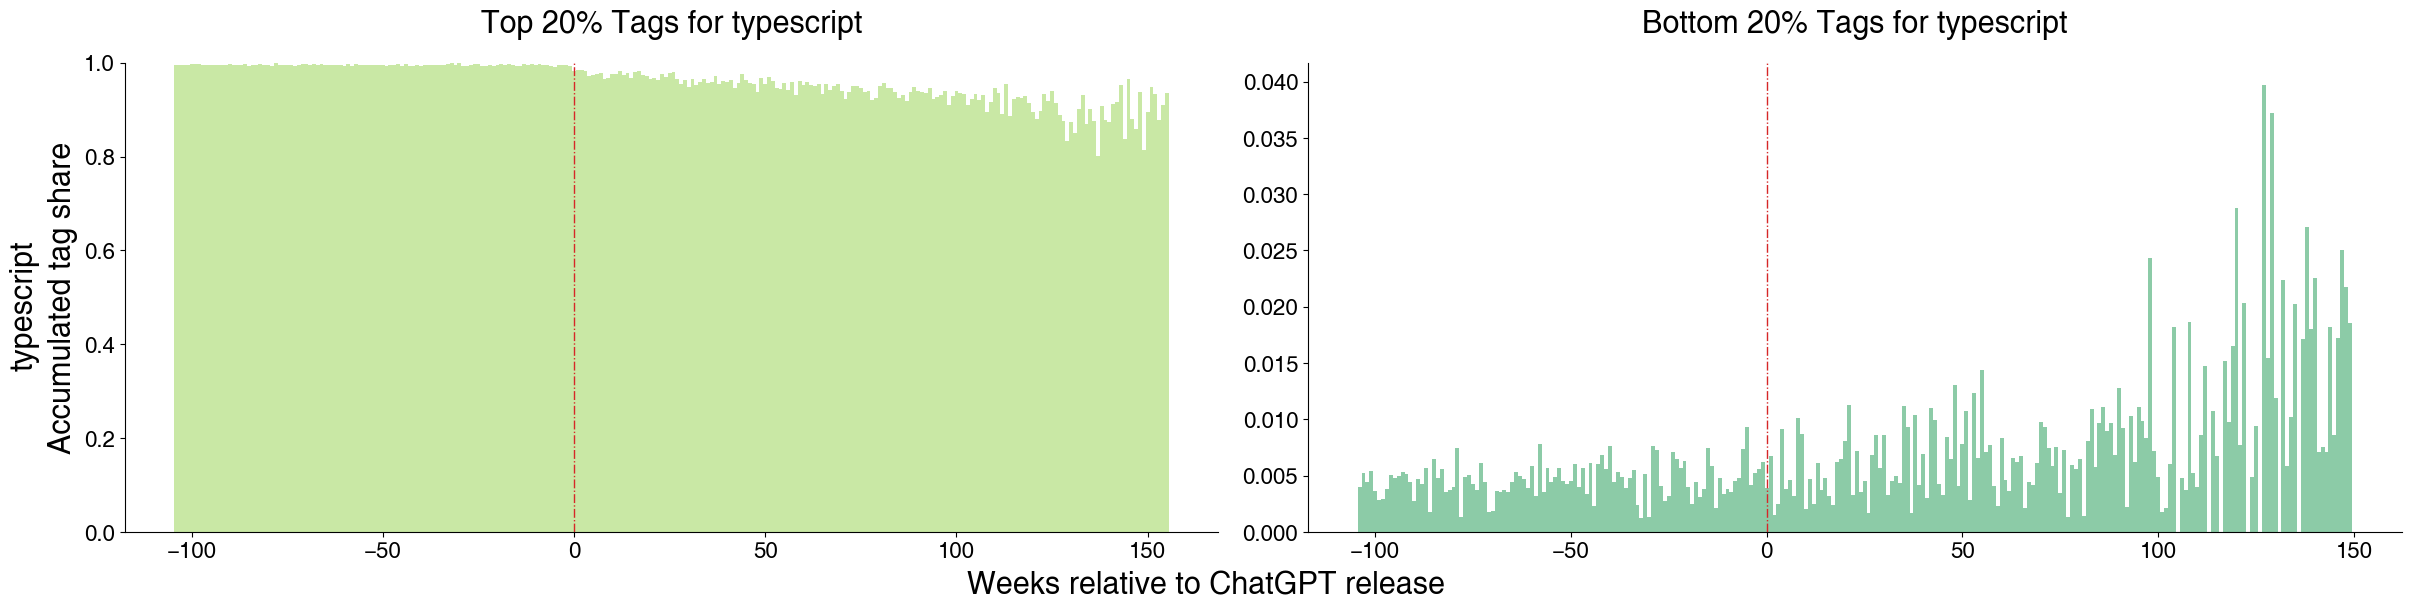

In [18]:
sharey = False ## 또는 sharey=False
sharex = True ## 또는 sharex=False

fig, axs = plt.subplots(1, 2, figsize = (24, 6), constrained_layout=True)
alpha_list = [0.6, 0.5]
color_list = ["#a6d96a", "#1a9850"]

for x, (title, proportion) in enumerate(proportion_dict.items()):
    rel_week = list(proportion['rel_week'])
    values = list(proportion['pct_pct'])
    
    axs[x].bar(rel_week, values, color=color_list[x], width=1.0, align='center', alpha=alpha_list[x])
    axs[x].axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)

    if x ==0 :
        axs[x].set_ylim(0, 1.0)
        # axs[x].set_yticks(np.arange(0.85, 1.01, 0.05))


    axs[x].text(0.5, 1.05, f'{title} for {option_dict["selected_tags"]}',
            ha='center', va='bottom', fontsize=22, fontweight='bold', transform=axs[x].transAxes)

    axs[x].text(0.5, 1.00, "",
        ha='center', va='bottom', fontsize=15, transform=axs[x].transAxes)  
    axs[x].tick_params(axis='x', labelsize=16)
    axs[x].tick_params(axis='y', labelsize=16)
    axs[x].spines['top'].set_visible(False)
    axs[x].spines['right'].set_visible(False)





axs[0].set_ylabel("Accumulated tag share", fontsize = 22)

fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
fig.supylabel(f"{option_dict['selected_tags']}", fontsize=22)
plt.savefig(f"{output_dir}{option_dict['model']}_{option_dict['year_range']}", dpi=300, bbox_inches='tight')
plt.show();

ValueError: data type must provide an itemsize

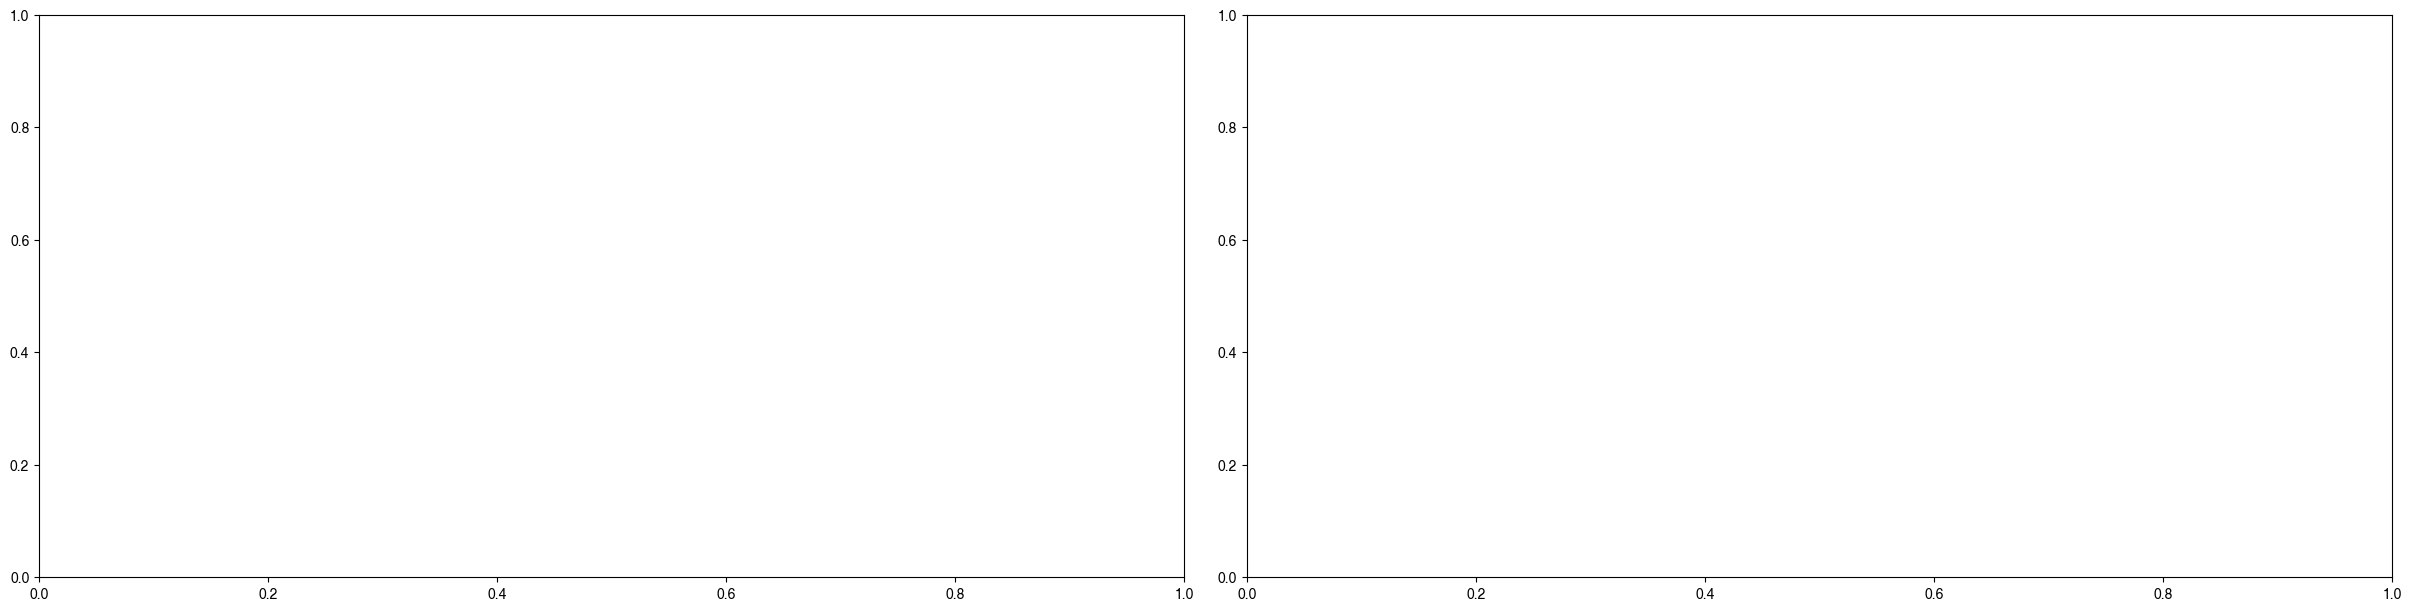

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)

panel_labels = ['A', 'B', 'C', 'D']
color_list = ["#a6d96a", "#1a9850"]
alpha_list = [0.6, 0.5]
### stacked topic plots
for i, (title, proportion) in enumerate(proportion_dict.items()):
    plot_regression(
        axs[i],
        proportion,
        title,
    )
    

fig.supxlabel("Week relative to ChatGPT release", fontsize=22)
fig.supylabel({option_dict['selected_tags']}, fontsize=22)

plt.savefig(f"{output_dir}{option_dict['model']}_{option_dict['year_range']}", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plot_gen = PlotGen.PlotGen()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)

panel_labels = ['A', 'B', 'C', 'D']
color_list = ["#a6d96a", "#1a9850"]
alpha_list = [0.6, 0.5]
### stacked topic plots
for i, (title, proportion) in enumerate(proportion_dict.items()):
    plot_gen.draw_tag_bar(
        axs[i],
        title,
        proportion,
        color_list[i],
        alpha_list[i],
        panel_labels[i]
    )
    

fig.supxlabel("Week relative to ChatGPT release", fontsize=22)

plt.savefig(f"{output_dir}{option_dict['model']}_{option_dict['year_range']}", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(24, 6), constrained_layout=True)

panel_labels = ['A', 'B', 'C', 'D']
color_list = ["#a6d96a", "#1a9850"]
alpha_list = [0.6, 0.5]
### stacked topic plots
for i, (title, proportion) in enumerate(proportion_dict.items()):
    plot_gen.plot_regression(
        axs[i],
        title,
        proportion,
        color_list[i],
        alpha_list[i],
        panel_labels[i]
    )
    

fig.supxlabel("Week relative to ChatGPT release", fontsize=22)

plt.savefig(f"{output_dir}{option_dict['model']}_{option_dict['year_range']}", dpi=300, bbox_inches='tight')
plt.show()